<a href="https://colab.research.google.com/github/camistrika/BETO_HUMOR/blob/main/notebooks/final_model_lora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo final — BETO + LoRA

In [1]:
!git clone https://github.com/camistrika/BETO_HUMOR.git
%cd BETO_HUMOR
!pip install -e . -q

Cloning into 'BETO_HUMOR'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (217/217), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 217 (delta 109), reused 178 (delta 84), pack-reused 0 (from 0)
Receiving objects: 100% (217/217), 3.53 MiB | 31.44 MiB/s, done.
Resolving deltas: 100% (109/109), done.
/content/BETO_HUMOR
  Preparing metadata (setup.py) ... done


In [1]:
!pip install -q torchao --upgrade
!pip install -q transformers peft datasets scikit-learn pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 113.1 MB/s eta 0:00:00


In [2]:
%cd /content/BETO_HUMOR

/content/BETO_HUMOR


In [3]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import shutil
from google.colab import files
import json

from betohumor.config import DataConfig, BetoConfig, LoraConfig
from betohumor.utils import set_seed
from betohumor.dataset import load_and_split, HahaDataset
from betohumor.models.lora import build_beto_lora
from betohumor.train import train_model
from betohumor.metrics import get_best_macro_f1_from_history, get_training_history
from betohumor.plots import plot_training_curves

## 1. Mejor configuración (resultado del CV)
Completar con los valores reales que ganaron en `cross_validation_lora.ipynb`.

In [4]:
BEST_R     = 32
BEST_ALPHA = 64
BEST_LR    = 1e-4
BEST_WD    = 0.05

## 2. Datos: train + val combinados



In [5]:
data_config  = DataConfig(data_path = "data/raw/haha_2019_train.csv")
beto_config = BetoConfig()
set_seed(data_config.seed)

df_train, df_val, df_test = load_and_split(data_config)
df_combined = pd.concat([df_train, df_val]).reset_index(drop=True)

df_train_final, df_val_final = train_test_split(
    df_combined, test_size=0.05,
    stratify=df_combined[data_config.label_col],
    random_state=data_config.seed,
)

print(f'Train final: {len(df_train_final)} | Val: {len(df_val_final)}')

Train: 19197 | Val: 2397 | Test: 2400
Train final: 20514 | Val: 1080


## 3. Entrenar el modelo final

In [6]:
tokenizer = AutoTokenizer.from_pretrained(beto_config.base_model)

train_dataset = HahaDataset(df_train_final, tokenizer, data_config)
val_dataset   = HahaDataset(df_val_final,   tokenizer, data_config)

lora_config = LoraConfig(r=BEST_R, lora_alpha=BEST_ALPHA)
model = build_beto_lora(beto_config, lora_config)

trainer = train_model(
    model, train_dataset, val_dataset, beto_config,
    output_dir='results/final_lora',
    seed=data_config.seed,
    learning_rate=BEST_LR,
    weight_decay=BEST_WD,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

trainable params: 1,181,186 || all params: 111,033,604 || trainable%: 1.0638


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

{'loss': '0.7052', 'grad_norm': '1.63', 'learning_rate': '6.625e-06', 'epoch': '1'}
{'eval_loss': '0.6843', 'eval_accuracy': '0.5898', 'eval_macro_f1': '0.5782', 'eval_runtime': '0.7204', 'eval_samples_per_second': '1499', 'eval_steps_per_second': '12.49', 'epoch': '1'}
  Época 1 | val_loss=0.6843 | macro_f1=0.5782 | accuracy=0.5898
{'loss': '0.6375', 'grad_norm': '1.802', 'learning_rate': '1.329e-05', 'epoch': '2'}
{'eval_loss': '0.529', 'eval_accuracy': '0.7333', 'eval_macro_f1': '0.7288', 'eval_runtime': '0.7095', 'eval_samples_per_second': '1522', 'eval_steps_per_second': '12.69', 'epoch': '2'}
  Época 2 | val_loss=0.5290 | macro_f1=0.7288 | accuracy=0.7333
{'loss': '0.4649', 'grad_norm': '2.266', 'learning_rate': '1.996e-05', 'epoch': '3'}
{'eval_loss': '0.4108', 'eval_accuracy': '0.8046', 'eval_macro_f1': '0.7967', 'eval_runtime': '0.7059', 'eval_samples_per_second': '1530', 'eval_steps_per_second': '12.75', 'epoch': '3'}
  Época 3 | val_loss=0.4108 | macro_f1=0.7967 | accuracy=0

## 4. Curva de entrenamiento

Macro F1: 0.8592


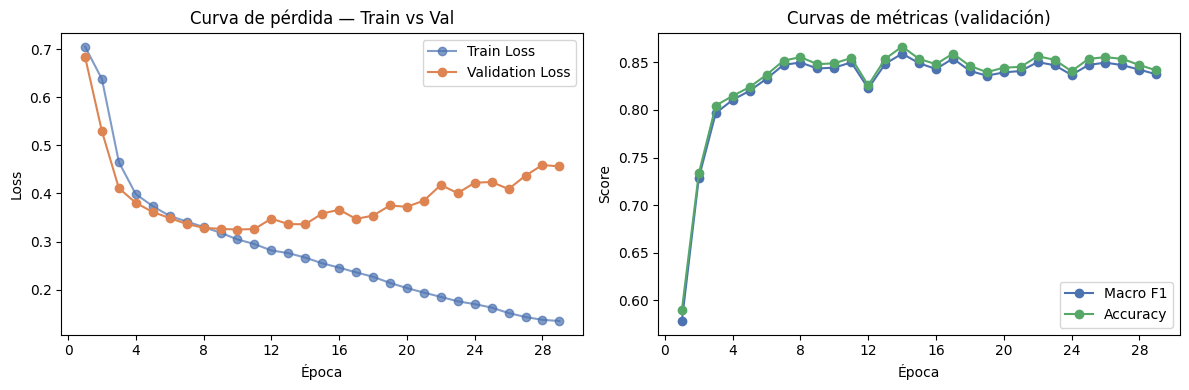

In [7]:
history = get_training_history(trainer)
macro_f1 = get_best_macro_f1_from_history(trainer)

print(f'Macro F1: {macro_f1:.4f}')
_ = plot_training_curves(history)

## 5. Guardar el modelo final

In [8]:
trainer.save_model('results/final_lora')
tokenizer.save_pretrained('results/final_lora')

('results/final_lora/tokenizer_config.json',
 'results/final_lora/tokenizer.json')

In [12]:
with open('results/final_lora/training_history.json', 'w') as f:
    json.dump({
        'best_macro_f1': macro_f1,
        'train_epochs': history['train_epochs'],
        'train_loss': history['train_loss'],
        'eval_epochs': history['eval_epochs'],
        'eval_loss': history['eval_loss'],
        'macro_f1_por_epoca': history['macro_f1'],
        'accuracy_por_epoca': history['accuracy'],
    }, f, indent=2)
print('Historial guardado')

for folder in os.listdir('results/final_lora'):
    if folder.startswith('checkpoint'):
        shutil.rmtree(os.path.join('results/final_lora', folder))

shutil.make_archive('final_lora', 'zip', 'results/final_lora')
files.download('final_lora.zip')

Historial guardado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>